# Method: CNN(Feature Extraction) + DBSCAN(Detection)

Code Flow
1. Imports + Setup + Model
2. Feature Extraction
3. Data Loading
4. Visualize latent vector space in t-SNE
5. Parameter Optimization: Manual Grid Search & Optuna
6. Metrics & Evaluation
8. Confusion Matrix
9. TP/FP Image Examples & Review
10. Additional Visualization

In [2]:
# 1. Imports & Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets.folder import default_loader
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, precision_recall_curve, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, auc
)
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
import optuna
import warnings
import random
from tqdm import tqdm
from PIL import Image

%matplotlib inline
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Set global random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# 2. Feature Extraction
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval().to(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def extract_deep_features(img_paths):
    features = []
    for path in tqdm(img_paths, desc="Extracting features"):
        img = default_loader(path)
        img = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = model(img).squeeze().cpu().numpy()
        features.append(feat)
    return np.array(features)

In [4]:
# 3. Data Loading

base_path = "C:/Users/seony/Desktop/ML2/Assignment 5/hazelnut"
train_good_dir = os.path.join(base_path, 'train', 'good')

# Define test directories and labels (0 for normal, 1 for anomaly)
test_dirs = {
    'good': 0,
    'crack': 1,
    'cut': 1,
    'hole': 1,
    'print': 1
}

# Load and sort training images (normal images only from 'good' folder)
train_paths = sorted([
    os.path.join(train_good_dir, f)
    for f in os.listdir(train_good_dir)
    if f.lower().endswith('.png')
])
train_features = extract_deep_features(train_paths)

# Load and sort test images from all test subfolders
test_paths, test_labels, test_features = [], [], []
for folder, label in test_dirs.items():
    folder_path = os.path.join(base_path, 'test', folder)
    filenames = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith('.png')
    ])
    img_list = [os.path.join(folder_path, f) for f in filenames]
    
    feats = extract_deep_features(img_list)
    
    test_paths.extend(img_list)
    test_labels.extend([label] * len(img_list))
    test_features.extend(feats)

# Convert test data to NumPy arrays
test_features = np.array(test_features)
test_labels = np.array(test_labels)

# Create binary ground truth labels (1 = anomaly, 0 = normal)
true_bin = np.array([1 if y == 1 else 0 for y in test_labels])

# Load test images in the same order as test_paths
test_images = [transform(default_loader(p)) for p in test_paths]

Extracting features: 100%|█████████████████████████████████████████████████████████████| 17/17 [00:02<00:00,  7.07it/s]


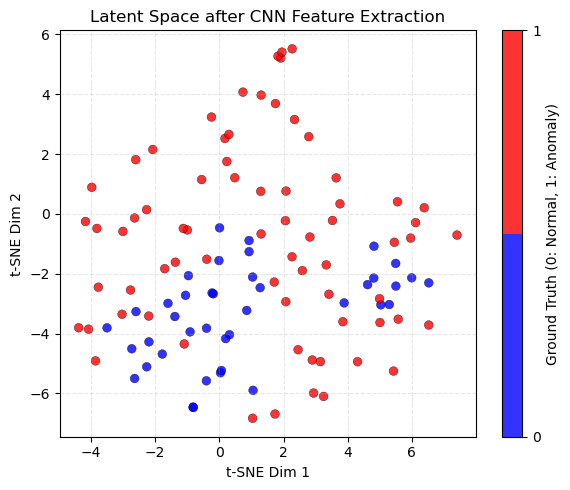

In [5]:
# 4. Visualize latent space using t-SNE
z_2d = TSNE(n_components=2, random_state=42).fit_transform(test_features)

#. Plot(0=blue, 1=red)
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    z_2d[:, 0], z_2d[:, 1],
    c=true_bin,
    cmap=plt.cm.get_cmap("bwr", 2),
    s=40, alpha=0.8, edgecolors="k", linewidths=0.3
)
plt.title("Latent Space after CNN Feature Extraction", fontsize=12)
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.colorbar(scatter, ticks=[0, 1], label="Ground Truth (0: Normal, 1: Anomaly)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# 5. Parameter optimization 1) Manual Grid Search
manual_eps = [0.5, 1.0, 1.5]
manual_min_samples = [10, 20]
results = []

for min_samples in manual_min_samples:
    for eps in manual_eps:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        combined = np.vstack([train_features, test_features])
        labels = db.fit_predict(combined)
        test_pred = labels[len(train_features):]
        pred_bin = (test_pred == -1).astype(int)

        nn = NearestNeighbors(n_neighbors=2)
        nn.fit(train_features)
        distances, _ = nn.kneighbors(test_features)
        scores = distances[:, 1]

        P = precision_score(test_labels, pred_bin, average='weighted', zero_division=0)
        R = recall_score(test_labels, pred_bin, average='weighted', zero_division=0)
        F = f1_score(test_labels, pred_bin, average='weighted', zero_division=0)
        A = accuracy_score(test_labels, pred_bin)
        try:
            pr_auc = roc_auc_score(test_labels, pred_bin)
            roc_auc = roc_auc_score(test_labels, pred_bin)
        except:
            pr_auc = roc_auc = 0.0

        results.append({
            "Model": "Manual",
            "eps": eps,
            "min_samples": min_samples,
            "Accuracy": A,
            "Precision": P,
            "Recall": R,
            "F1 Score": F,
            "ROC AUC": roc_auc,
            "PR AUC": pr_auc,
            "Support": len(test_labels),
            "Mean Score": np.mean(scores)
        })

In [7]:
# 5. Parameter optimization 2)  Optuna Optimization - selected
def objective(trial):
    eps = trial.suggest_float('eps', 0.3, 2.0)
    min_samples = trial.suggest_int('min_samples', 3, 20)
    db = DBSCAN(eps=eps, min_samples=min_samples)
    combined = np.vstack([train_features, test_features])
    labels = db.fit_predict(combined)
    y_pred = (labels[len(train_features):] == -1).astype(int)
    if len(np.unique(y_pred)) < 2:
        return 0.0
    return roc_auc_score(test_labels, y_pred)

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)

In [8]:
# 6. Evaluate Best Model(Parameters from Optuna Best)

# Retrieve best hyperparameters from Optuna
best_eps = study.best_params['eps']
best_min_samples = study.best_params['min_samples']

# Fit DBSCAN on combined train + test features
db = DBSCAN(eps=best_eps, min_samples=best_min_samples)
combined = np.vstack([train_features, test_features])
labels = db.fit_predict(combined)  # DBSCAN cluster labels for all samples

# Convert DBSCAN output (-1 = outlier) to binary prediction for test set
#    -1 → 1 (anomaly), else → 0 (normal)
pred_bin = (labels[len(train_features):] == -1).astype(int)

# Compute distance-based anomaly scores using k-nearest neighbors
nn = NearestNeighbors(n_neighbors=2)
nn.fit(train_features)
distances, _ = nn.kneighbors(test_features)
scores = distances[:, 1]

# Build ground-truth binary array
true_bin = (np.array(test_labels) == 1).astype(int)

# Compute evaluation metrics
pr_prec, pr_rec, _ = precision_recall_curve(true_bin, scores)
pr_auc = auc(pr_rec, pr_prec)
roc_auc = roc_auc_score(true_bin, scores)
acc = accuracy_score(true_bin, pred_bin)
prec = precision_score(true_bin, pred_bin, zero_division=0)
rec = recall_score(true_bin, pred_bin, zero_division=0)
f1 = f1_score(true_bin, pred_bin, zero_division=0)

# Save result to summary
result = {
    "Model": "Optuna Best",
    "eps": best_eps,
    "min_samples": best_min_samples,
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "ROC AUC": roc_auc,
    "PR AUC": pr_auc,
    "Support": len(test_labels),
    "Mean Score": np.mean(scores)
}

results.append(result)

# Display summary table
df_all_results = pd.DataFrame(results).sort_values(['Model','eps'])
pd.set_option("display.max_colwidth", None)
print("Full Summary Table (Manual Grid + Optuna)")
display(df_all_results.round(4))

Full Summary Table (Manual Grid + Optuna)


,Model,eps,min_samples,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Support,Mean Score
0,Manual,0.5000,10,0.6364,0.4050,0.6364,0.4949,0.5000,0.5000,110,9.7639
3,Manual,0.5000,20,0.6364,0.4050,0.6364,0.4949,0.5000,0.5000,110,9.7639
1,Manual,1.0000,10,0.6364,0.4050,0.6364,0.4949,0.5000,0.5000,110,9.7639
4,Manual,1.0000,20,0.6364,0.4050,0.6364,0.4949,0.5000,0.5000,110,9.7639
2,Manual,1.5000,10,0.6364,0.4050,0.6364,0.4949,0.5000,0.5000,110,9.7639
5,Manual,1.5000,20,0.6364,0.4050,0.6364,0.4949,0.5000,0.5000,110,9.7639
6,Optuna Best,0.9367,20,0.6364,0.6364,1.0000,0.7778,0.9507,0.9747,110,9.7639


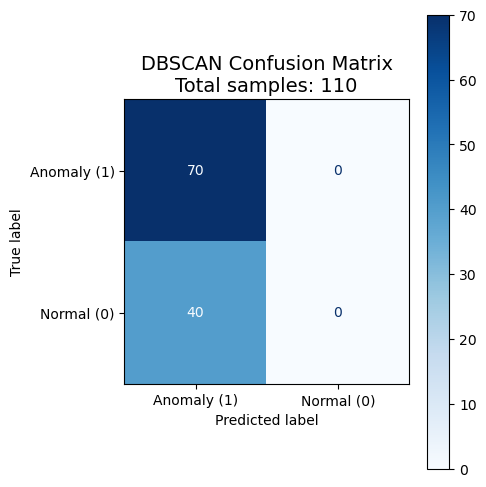

In [9]:
# 7. Confusion Matrix (Optuna Best)
cm = confusion_matrix(true_bin, pred_bin, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Anomaly (1)', 'Normal (0)'])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'DBSCAN Confusion Matrix\nTotal samples: {cm.sum()}', fontsize=14)
plt.tight_layout()
plt.show()

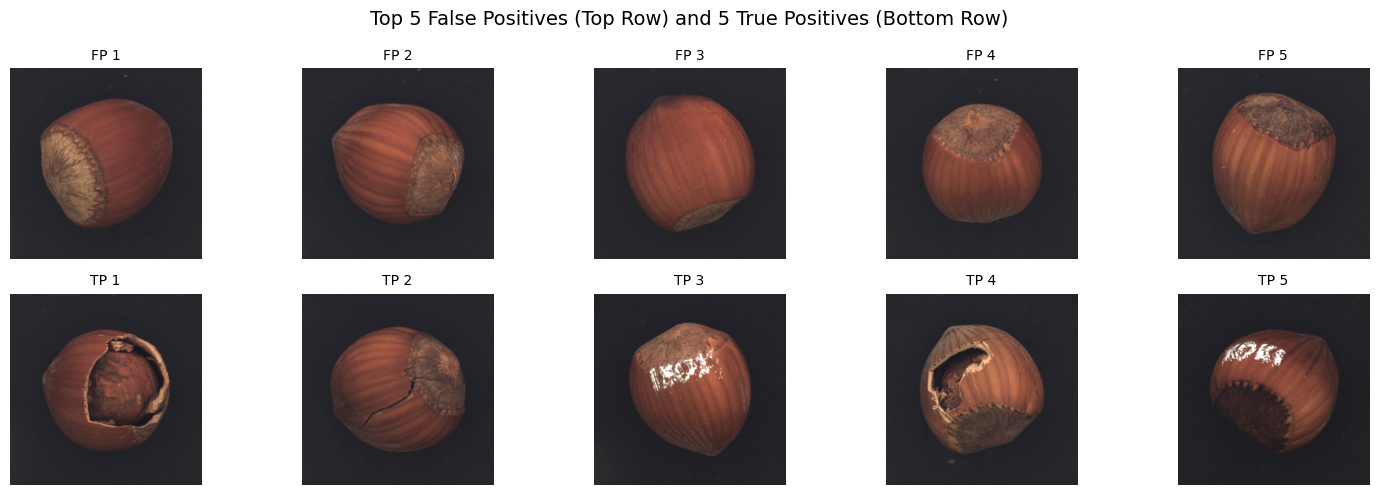

In [10]:
#8. Top 5 False/True Positive Examples
import matplotlib.pyplot as plt
from PIL import Image
import random

# classification criteria
tp_indices = [i for i in range(len(true_bin)) if true_bin[i] == 1 and pred_bin[i] == 1]
fp_indices = [i for i in range(len(true_bin)) if true_bin[i] == 0 and pred_bin[i] == 1]

# Samples from each group
selected_fp = random.sample(fp_indices, min(5, len(fp_indices)))
selected_tp = random.sample(tp_indices, min(5, len(tp_indices)))

plt.figure(figsize=(15, 5))

# Top: False Positives
for idx, i in enumerate(selected_fp):
    img = Image.open(test_paths[i])
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.title(f"FP {idx + 1}", fontsize=10)
    plt.axis("off")

# Bottom: True Positives
for idx, i in enumerate(selected_tp):
    img = Image.open(test_paths[i])
    plt.subplot(2, 5, 5 + idx + 1)
    plt.imshow(img)
    plt.title(f"TP {idx + 1}", fontsize=10)
    plt.axis("off")

plt.suptitle("Top 5 False Positives (Top Row) and 5 True Positives (Bottom Row)", fontsize=14)
plt.tight_layout()
plt.show()

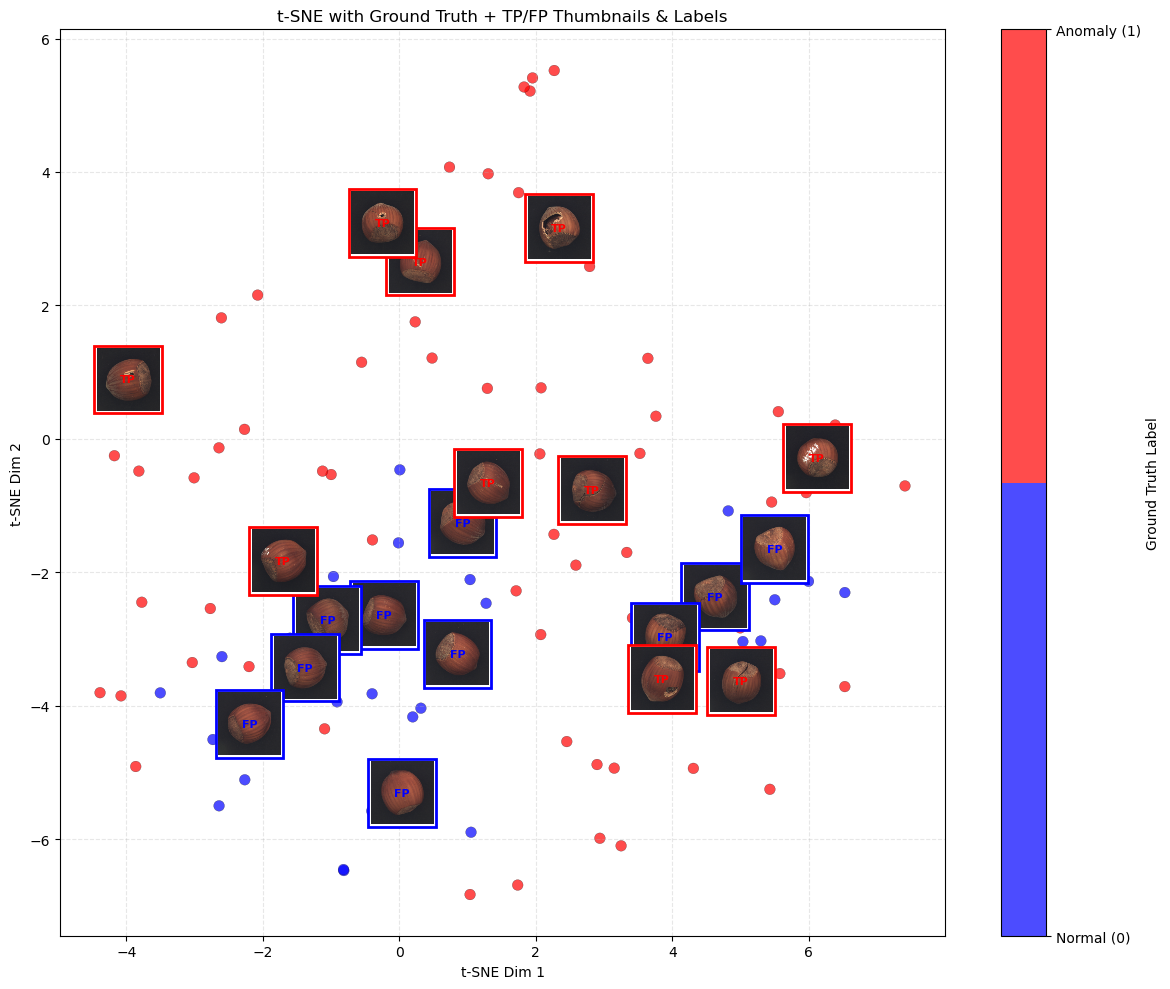

In [11]:
#9. Visualize t-SNE with Ground Truth + TP/FP Text & Thumbnails Overlay

import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from torchvision.datasets.folder import default_loader

# Load test_images in exact same order as test_paths
test_images = [transform(default_loader(p)) for p in test_paths]

# Build ground-truth binary array (1=anomaly, 0=normal)
true_bin = (np.array(test_labels) == 1).astype(int)

# Fit DBSCAN with Optuna best params and compute pred_bin
db = DBSCAN(eps=best_eps, min_samples=best_min_samples)
combined = np.vstack([train_features, test_features])
combined_labels = db.fit_predict(combined)
pred_bin = (combined_labels[len(train_features):] == -1).astype(int)

# Compute t-SNE embedding
z_2d = TSNE(n_components=2, random_state=42).fit_transform(test_features)

# Draw base scatter colored by true labels
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(
    z_2d[:, 0], z_2d[:, 1],
    c=true_bin,
    cmap=plt.cm.get_cmap("bwr", 2),
    s=60, alpha=0.7,
    edgecolors="k", linewidths=0.2,
    zorder=1
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Normal (0)", "Anomaly (1)"])
cbar.set_label("Ground Truth Label", fontsize=10)

# Identify TP and FP indices
tp_indices = [i for i, (t, p) in enumerate(zip(true_bin, pred_bin)) if t==1 and p==1]
fp_indices = [i for i, (t, p) in enumerate(zip(true_bin, pred_bin)) if t==0 and p==1]

# Sample up to 10 examples each
N = 10
tp_sample = random.sample(tp_indices, min(len(tp_indices), N))
fp_sample = random.sample(fp_indices, min(len(fp_indices), N))

# Overlay thumbnails
def overlay_thumbs(indices, color):
    """
    Overlay image thumbnails at their t-SNE coords with colored border.
    """
    for idx in indices:
        x, y = z_2d[idx]
        img = test_images[idx].permute(1, 2, 0).cpu().numpy()
        img = np.clip(img, 0, 1)
        thumb = OffsetImage(img, zoom=0.2)
        box = AnnotationBbox(
            thumb, (x, y),
            frameon=True, pad=0.2,
            bboxprops=dict(edgecolor=color, linewidth=2),
            zorder=2
        )
        ax.add_artist(box)

# Draw FP thumbnails first, then TP so TP are on top
overlay_thumbs(fp_sample, color="blue")
overlay_thumbs(tp_sample, color="red")

# Overlay TP/FP text labels
for idx in fp_sample:
    x, y = z_2d[idx]
    ax.text(x, y, "FP", color="blue", fontsize=8, fontweight="bold",
            ha="center", va="center", zorder=3)
for idx in tp_sample:
    x, y = z_2d[idx]
    ax.text(x, y, "TP", color="red", fontsize=8, fontweight="bold",
            ha="center", va="center", zorder=4)

# Final formatting
ax.set_title("t-SNE with Ground Truth + TP/FP Thumbnails & Labels", fontsize=12)
ax.set_xlabel("t-SNE Dim 1")
ax.set_ylabel("t-SNE Dim 2")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()